# Customer Retention & Revenue Analysis — Online Retail II

**Business question:** A UK-based online giftware retailer wants to know where its
revenue actually comes from, how well it retains new customers, and which customer
segments deserve marketing spend.

**Data:** [UCI Online Retail II](https://archive.ics.uci.edu/dataset/502/online+retail+ii) —
~1.07M real transaction rows from Dec 2009 to Dec 2011.

**Pipeline:** `src/prepare_data.py` cleans the raw Excel file (dedupes rows, nets out
cancelled orders against their original purchases, removes fees/adjustments) and writes
the parquet file this notebook reads. The same analyses are reproduced in pure SQL in
`sql/analysis_queries.sql`.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
df = pd.read_parquet(ROOT / "data" / "processed" / "transactions_clean.parquet")
cust = df[df["customer_id"].notna()].copy()  # identified customers only

plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "figure.dpi": 110})
ACCENT, GREY = "#2563eb", "#9ca3af"

df.head()


,invoice,stock_code,description,quantity,invoice_date,price,customer_id,country,revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0


## 1. Headline KPIs

In [2]:
orders_per_customer = cust.groupby("customer_id")["invoice"].nunique()
cust_rev = cust.groupby("customer_id").agg(revenue=("revenue", "sum"), orders=("invoice", "nunique"))

kpis = pd.Series({
    "Total revenue": f"£{df['revenue'].sum() / 1e6:.2f}M",
    "Orders": f"{df['invoice'].nunique():,}",
    "Identified customers": f"{cust['customer_id'].nunique():,}",
    "Average order value": f"£{df.groupby('invoice')['revenue'].sum().mean():.0f}",
    "Repeat-purchase rate": f"{(orders_per_customer > 1).mean():.1%}",
    "Revenue from repeat buyers": f"{cust_rev.loc[cust_rev['orders'] > 1, 'revenue'].sum() / cust_rev['revenue'].sum():.1%}",
})
kpis.to_frame("value")


,value
Total revenue,£19.09M
Orders,"39,231"
Identified customers,"5,835"
Average order value,£487
Repeat-purchase rate,72.4%
Revenue from repeat buyers,96.7%


Nearly **97% of customer revenue comes from repeat buyers**, so retention — not
acquisition — is the lever that moves this business.


## 2. Monthly revenue trend

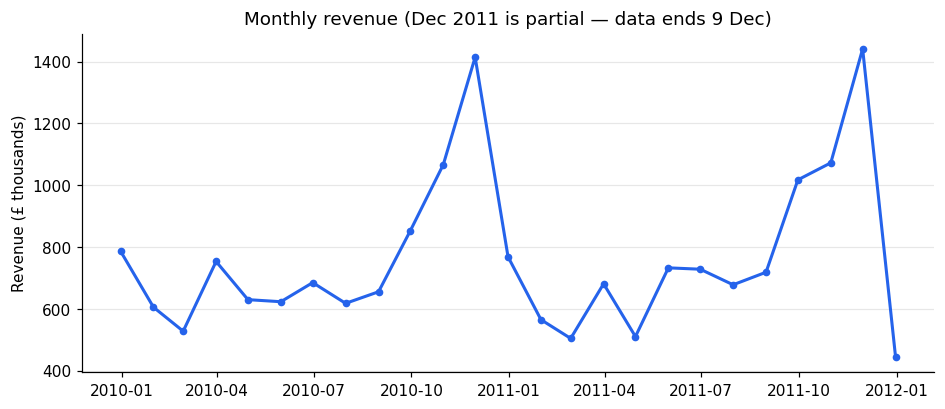

In [3]:
monthly = df.set_index("invoice_date").resample("ME")["revenue"].sum()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(monthly.index, monthly / 1e3, color=ACCENT, lw=2, marker="o", ms=4)
ax.set_title("Monthly revenue (Dec 2011 is partial — data ends 9 Dec)")
ax.set_ylabel("Revenue (£ thousands)")
ax.grid(axis="y", alpha=0.3)
plt.show()


Revenue is strongly seasonal: September–November build to a **November peak of ~£1.4M**
(2.5–3x the spring trough) as wholesale buyers stock up for Christmas. Inventory and
campaign planning should anchor on that Q4 ramp.


## 3. Cohort retention

Group customers by the month of their first purchase, then track what share of each
cohort places another order in the months that follow.


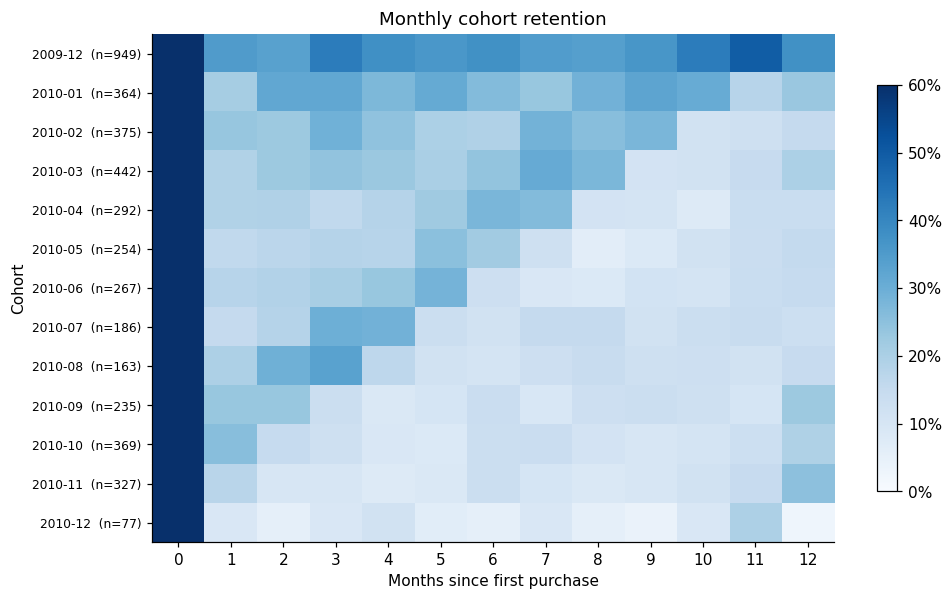

Average month-1 retention: 20.8%


In [4]:
orders = (
    cust.groupby(["customer_id", "invoice"])
    .agg(order_month=("invoice_date", lambda s: s.min().to_period("M")))
    .reset_index()
)
first = orders.groupby("customer_id")["order_month"].min().rename("cohort")
orders = orders.join(first, on="customer_id")
orders["months_since"] = (orders["order_month"] - orders["cohort"]).map(lambda d: d.n)

counts = orders.groupby(["cohort", "months_since"])["customer_id"].nunique().unstack(fill_value=0)
retention = counts.div(counts[0], axis=0)

r = retention.iloc[:13, :13]
fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(r.values, cmap="Blues", vmin=0, vmax=0.6, aspect="auto")
ax.set_xticks(range(r.shape[1]), labels=[str(c) for c in r.columns])
ax.set_yticks(range(r.shape[0]), labels=[f"{i}  (n={counts.loc[i, 0]:,})" for i in r.index], fontsize=8)
ax.set_xlabel("Months since first purchase"); ax.set_ylabel("Cohort")
ax.set_title("Monthly cohort retention")
fig.colorbar(im, shrink=0.8, format=lambda x, _: f"{x:.0%}")
plt.show()

print(f"Average month-1 retention: {retention.iloc[:-1, 1].mean():.1%}")


Roughly **1 in 5 new customers comes back the following month**, and retention then
stabilises around 20–25% rather than decaying to zero — the customers who survive the
first month become a durable repeat base. The first repeat purchase is the critical
conversion: a post-first-order email/offer sequence in the first 30 days targets exactly
this drop-off. The December 2009 cohort (n=949, likely the retailer's longest-standing
buyers) retains at 30–40%+ for two full years.


## 4. RFM segmentation

Score every customer 1–5 on Recency, Frequency and Monetary value (quintiles), then map
score combinations to named, actionable segments.


In [5]:
snapshot = cust["invoice_date"].max() + pd.Timedelta(days=1)
rfm = cust.groupby("customer_id").agg(
    recency_days=("invoice_date", lambda s: (snapshot - s.max()).days),
    frequency=("invoice", "nunique"),
    monetary=("revenue", "sum"),
)
rfm["R"] = pd.qcut(rfm["recency_days"], 5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm["F"] = pd.qcut(rfm["frequency"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm["M"] = pd.qcut(rfm["monetary"], 5, labels=[1, 2, 3, 4, 5]).astype(int)

def segment(row):
    if row["R"] >= 4 and row["F"] >= 4: return "Champions"
    if row["R"] >= 3 and row["F"] >= 3: return "Loyal"
    if row["M"] >= 4 and row["R"] >= 2: return "Big spenders"
    if row["R"] >= 4: return "Promising"
    if row["R"] <= 2 and row["F"] >= 3: return "At risk"
    return "Hibernating"

rfm["segment"] = rfm.apply(segment, axis=1)

seg = rfm.groupby("segment").agg(
    customers=("segment", "size"), revenue=("monetary", "sum"),
    avg_recency=("recency_days", "mean"), avg_orders=("frequency", "mean"),
).sort_values("revenue", ascending=False)
seg["revenue_share"] = seg["revenue"] / seg["revenue"].sum()
seg["customer_share"] = seg["customers"] / seg["customers"].sum()
seg.round(2)


,customers,revenue,avg_recency,avg_orders,revenue_share,customer_share
segment,,,,,,
Champions,1478,11623163.07,20.39,15.43,0.70,0.25
Loyal,1201,2327878.65,78.27,5.32,0.14,0.21
Big spenders,316,1043065.45,249.57,5.92,0.06,0.05
Hibernating,1825,704731.41,392.71,1.26,0.04,0.31
At risk,596,639779.01,396.63,3.92,0.04,0.10
Promising,419,173096.44,28.52,1.44,0.01,0.07


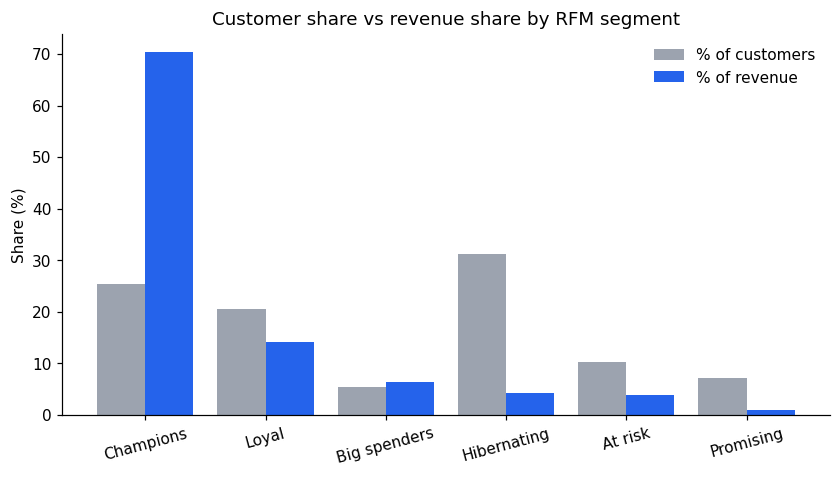

In [6]:
fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(seg))
ax.bar(x - 0.2, seg["customer_share"] * 100, width=0.4, label="% of customers", color=GREY)
ax.bar(x + 0.2, seg["revenue_share"] * 100, width=0.4, label="% of revenue", color=ACCENT)
ax.set_xticks(x, labels=seg.index, rotation=15)
ax.set_ylabel("Share (%)"); ax.legend(frameon=False)
ax.set_title("Customer share vs revenue share by RFM segment")
plt.show()


**A quarter of customers (Champions) generate 70% of revenue.** Meanwhile the
"At risk" segment — formerly frequent buyers who haven't ordered in ~13 months —
still represents £640K of historical revenue walking out the door. The marketing
playbook falls straight out of the table: protect Champions (early access, service
priority), win back At-risk with targeted offers, and don't overspend on Hibernating
one-time buyers.


## 5. What sells, and where

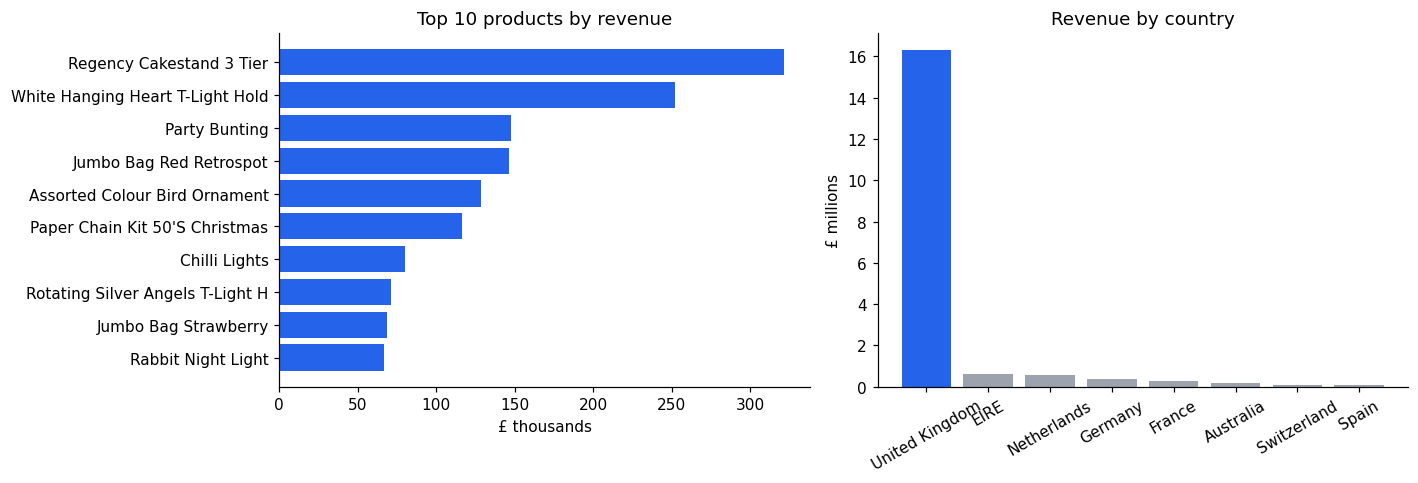

UK share of revenue: 85.5%


In [7]:
top = df.groupby("description")["revenue"].sum().nlargest(10).sort_values()
geo = df.groupby("country")["revenue"].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].barh(top.index.str.title().str.slice(0, 32), top / 1e3, color=ACCENT)
axes[0].set_title("Top 10 products by revenue"); axes[0].set_xlabel("£ thousands")
g8 = geo.head(8)
axes[1].bar(g8.index, g8 / 1e6, color=[ACCENT if c == "United Kingdom" else GREY for c in g8.index])
axes[1].set_title("Revenue by country"); axes[1].set_ylabel("£ millions")
axes[1].tick_params(axis="x", rotation=30)
fig.tight_layout()
plt.show()

print(f"UK share of revenue: {geo['United Kingdom'] / geo.sum():.1%}")


## 6. Recommendations

1. **Launch a first-30-days onboarding flow.** Only ~21% of new customers return in
   month 1, yet repeat buyers drive 97% of revenue. Even a 3-point lift in month-1
   retention compounds across every future cohort.
2. **Protect the Champions segment.** 25% of customers → 70% of revenue. Loyalty perks
   and stock-priority for their top SKUs are cheap insurance on ~£11.6M of revenue.
3. **Run a win-back campaign on the At-risk segment** (~600 customers, ~4 orders each
   historically) before they lapse fully.
4. **Plan inventory around the Q4 wholesale ramp** — November revenue runs 2.5–3x the
   spring trough, and top SKUs are seasonal (Christmas paper chain kits, t-light holders).
5. **Test international growth.** 85% of revenue is UK; EIRE/Netherlands/Germany/France
   already buy at meaningful volume with zero localised marketing.

### Caveats
- ~23% of rows have no customer ID (guest checkouts / unregistered wholesale) and are
  excluded from customer-level analyses, but included in revenue totals.
- Cancelled orders are netted out against their original purchases in cleaning;
  unmatched cancellations are dropped.
- The dataset ends 9 Dec 2011, so the final month is partial.
